In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
sensitivity = pd.read_excel(
    "../../drug screening data//HTS_and_confirmation.xlsx",
    sheet_name="Training set",
)
sensitivity.head()

,SMILES,Supplier,Supplier Ref,CLNUMBER,Conc,%Inh CAPAN2,%Inh SW1990,%Inh BXPC3,%Inh HPAFII,%Inh CFPAC1,...,%Inh HEK293,positives CAPAN2,positives SW1990,positives BXPC3,positives HPAFII,positives CFPAC1,positives PANC10.05,positives AsPC-1,positives U2OS,positives HEK293
0,Cc1ccc2nc3c(c(Nc4ccccc4)c2c1)CCC3,ChemDiv (IRB library),3931-1998,CL3010,10 uM,34.59445,19.46375,10.36140,22.38685,22.96545,...,49.12555,1,0,0,1,0,0,0,0,1
1,O=C1c2ccccc2C(=O)c2c1cccc2N1CCC(O)CC1,ChemDiv (IRB library),6612-0273,CL0699,10 uM,71.84750,7.63780,8.73805,15.20475,6.18435,...,-3.11180,1,0,0,0,0,0,0,0,0
2,Cc1ccc2c(c1)c1c(n2CC(O)CNCc2ccccc2)CCCC1,ChemDiv (IRB library),6658-0003,CL1206,10 uM,37.81100,36.61605,6.38895,14.75835,19.22960,...,32.66685,1,0,0,0,0,1,0,0,0
3,c1ccc(-c2nc3c4c5c(sc4ncn3n2)CCCCC5)cc1,ChemDiv (IRB library),4072-2778,CL1989,10 uM,2.58995,-3.88405,-1.65090,-2.66615,-1.20870,...,-8.68985,0,0,0,0,0,0,0,0,0
4,CC(C)c1ccc(C2C3=C(CC(C)(C)CC3=O)Nc3nn(-c4ccccc...,ChemDiv (IRB library),6359-0280,CL4744,10 uM,4.33115,0.20310,-0.66100,-0.76515,3.78565,...,3.58205,0,0,0,0,0,0,0,0,0


In [3]:
clls = ["BXPC3", "CAPAN2", "CFPAC1", "HPAFII", "PANC10.05", "SW1990", "U2OS", "HEK293"]
int_clls = ["BXPC3", "CAPAN2", "CFPAC1", "HPAFII", "PANC10.05", "SW1990", "U2OS", "HEK293"]

cvcl = [
    "CVCL_0186",
    "CVCL_0026",
    "CVCL_1119",
    "CVCL_0313",
    "CVCL_1639",
    "CVCL_1723",
    "CVCL_0042",
    "CVCL_0045",
]
cll2cvcl = dict(zip(clls, cvcl))

In [4]:
sensitivity_continuous = sensitivity['%Inh ' + int_clls[0]].values
for cll in int_clls[1:]:
    sensitivity_continuous = np.vstack(
        [sensitivity_continuous, sensitivity['%Inh '+cll].values]
    )
    print(sensitivity_continuous.shape)

(2, 751)
(3, 751)
(4, 751)
(5, 751)
(6, 751)
(7, 751)
(8, 751)


In [5]:
sensitivity_binary = sensitivity['positives '+int_clls[0]].values
for cll in int_clls[1:]:
    sensitivity_binary = np.vstack(
        [sensitivity_binary, sensitivity['positives %s'%cll].values]
    )
    print(sensitivity_binary.shape)

(2, 751)
(3, 751)
(4, 751)
(5, 751)
(6, 751)
(7, 751)
(8, 751)


# GEx and mutations

In [6]:
gex = pd.read_excel(
    "../../RNAseq/raw_transcript_count.xlsx", sheet_name="raw counts"
)
gex.head()

,genes,U2OS_rep1,HEK293_rep1,PANC10.05_rep1,SW1990_rep1,CFPAC1_rep1,BXPC3_rep1,HPAFII_rep1,CAPAN2_rep1,U2OS_rep2,...,HPAFII_rep2,CAPAN2_rep2,U2OS_rep3,HEK293_rep3,PANC10.05_rep3,SW1990_rep3,CFPAC1_rep3,BXPC3_rep3,HPAFII_rep3,CAPAN2_rep3
0,DDX11L1,32,3,1,8,0,2,2,2,45,...,3,6,51,1,4,3,3,0,0,3
1,MIR6859-1,6,16,3,6,11,16,4,15,10,...,10,11,7,14,1,2,12,4,5,10
2,MIR1302-2,0,1,0,0,0,1,0,0,1,...,0,0,0,4,0,0,0,0,0,0
3,FAM138A,2,0,0,0,0,0,1,0,7,...,0,0,5,0,0,0,0,0,0,0
4,OR4F5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
for cll in clls:
    gex[cll+'_mean'] = gex.filter(like=cll).mean(axis=1)

In [8]:
gex_continuous = gex[clls[0] + "_mean"].values
for cll in clls[1:]:
    print(cll)
    gex_continuous = np.vstack([gex_continuous, gex[cll + "_mean"].values])
    print(gex_continuous.shape)

CAPAN2
(2, 24426)
CFPAC1
(3, 24426)
HPAFII
(4, 24426)
PANC10.05
(5, 24426)
SW1990
(6, 24426)
U2OS
(7, 24426)
HEK293
(8, 24426)


In [9]:
len(clls), len(gex_continuous)

(8, 8)

In [10]:
import pickle
with open(
    "../extra_data/mutation_profiles_from_drugcell.p",
    "rb",
) as f:
    cll2mut = pickle.load(f)

In [11]:
mut_embeddings = [cll2mut[cll] for cll in cvcl[:-1]]
mut_embeddings = np.vstack(mut_embeddings)
mut_embeddings.shape

(7, 3008)

In [12]:
# Different genes mutated
sum(mut_embeddings.sum(axis=0) > 0)

np.int64(291)

In [13]:
# Different genes mutated (only Pancreatic cell lines)
sum(mut_embeddings[:-1, :].sum(axis=0) > 0)

np.int64(236)

In [14]:
# mutations per cell line
mut_embeddings.sum(axis=1)

array([54, 40, 36, 46, 45, 52, 65])

In [15]:
mut_embeddings.shape

(7, 3008)

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr


# Compute pairwise distances
mut_distances = pairwise_distances(mut_embeddings, metric="jaccard")  # Binary distances
mut_distances_pc = pairwise_distances(
    mut_embeddings[:-1], metric="jaccard"
)  # Binary distances
sensitivity_dists_binary = pairwise_distances(
    sensitivity_binary, metric="jaccard"
)  # Binary distances
sensitivity_dists_binary_nohek = pairwise_distances(
    sensitivity_binary[:-1, :], metric="jaccard"
)  # Binary distances
sensitivity_dists_binary_pc = pairwise_distances(
    sensitivity_binary[:-2, :], metric="jaccard"
)  # Binary distances

gex_distances_nohek = pairwise_distances(
    gex_continuous[:-1, :], metric="cosine"
)  # Continuous distances
sensitivity_distances_nohek = pairwise_distances(
    sensitivity_continuous[:-1, :], metric="cosine"
)  # Continuous distances
gex_distances = pairwise_distances(
    gex_continuous, metric="cosine"
)  # Continuous distances
sensitivity_distances = pairwise_distances(
    sensitivity_continuous, metric="cosine"
)  # Continuous distances
gex_distances_pc = pairwise_distances(
    gex_continuous[:-2, :], metric="cosine"
)  # Continuous distances
sensitivity_distances_pc = pairwise_distances(
    sensitivity_continuous[:-2, :], metric="cosine"
)  # Continuous distances

In [17]:
# Flatten the upper triangle of the distance matrices
mut_distances_flat = mut_distances[np.triu_indices(mut_distances.shape[0], k=1)]
mut_distances_flat_pc = mut_distances_pc[np.triu_indices(mut_distances_pc.shape[0], k=1)]
gex_distances_flat_nohek = gex_distances_nohek[np.triu_indices(gex_distances_nohek.shape[0], k=1)]
gex_distances_flat = gex_distances[np.triu_indices(gex_distances.shape[0], k=1)]
sensitivity_distances_flat = sensitivity_distances[np.triu_indices(sensitivity_distances.shape[0], k=1)]
sensitivity_distances_flat_nohek = sensitivity_distances_nohek[np.triu_indices(sensitivity_distances_nohek.shape[0], k=1)]
sensitivity_distances_flat_pc = sensitivity_distances_pc[np.triu_indices(sensitivity_distances_pc.shape[0], k=1)]
gex_distances_flat_pc = gex_distances_pc[np.triu_indices(gex_distances_pc.shape[0], k=1)]

sensitivity_distances_flat_binary = sensitivity_dists_binary[np.triu_indices(sensitivity_dists_binary.shape[0], k=1)]
sensitivity_distances_flat_nohek_binary = sensitivity_dists_binary_nohek[np.triu_indices(sensitivity_dists_binary_nohek.shape[0], k=1)]
sensitivity_distances_flat_pc_binary = sensitivity_dists_binary_pc[np.triu_indices(sensitivity_dists_binary_pc.shape[0], k=1)]
# Compute Spearman correlation
correlation, p_value = spearmanr(mut_distances_flat, gex_distances_flat_nohek)

print(f"Spearman Correlation: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

Spearman Correlation: 0.034
P-value: 0.882


In [18]:
spearmanr(sensitivity_distances_flat_binary, gex_distances_flat)

SignificanceResult(statistic=np.float64(0.07800739090431827), pvalue=np.float64(0.6931682938796307))

In [19]:
spearmanr(sensitivity_distances_flat_pc, gex_distances_flat_pc)

SignificanceResult(statistic=np.float64(0.2714285714285714), pvalue=np.float64(0.3277893068411728))

In [20]:
spearmanr(sensitivity_distances_flat_pc, mut_distances_flat_pc)

SignificanceResult(statistic=np.float64(0.010714285714285713), pvalue=np.float64(0.9697698761545686))

In [21]:
spearmanr(sensitivity_distances_flat_nohek, mut_distances_flat)

SignificanceResult(statistic=np.float64(0.33582333697125133), pvalue=np.float64(0.13666627024235536))

In [22]:
def plot_correlation(ax, x, y, title, xlabel, ylabel, text_loc=(0.03, 0.6)):
    corr, p_val = spearmanr(x, y)
    ax.scatter(x, y, s=30, color="#738f9fff", edgecolor="black", alpha=0.8, zorder=2)
    stars = significance_stars(p_val)
    ax.text(
        text_loc[0],
        text_loc[1],
        f"Spearman rho: {corr:.2f}\np-value: {p_val:.1e}{stars}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        zorder=3,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(color="lightgray", linestyle="--", zorder=0)


def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

In [23]:
len(mut_distances_flat)

21

In [24]:
len(gex_distances_flat_nohek)

21

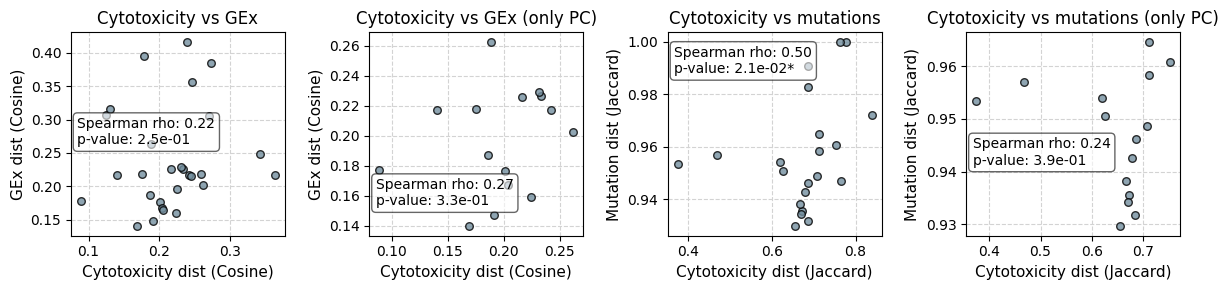

In [27]:
# Create the figure and subplots
fig, axes = plt.subplots(1, 4, figsize=(12, 3))  # 2x2 grid of subplots
fig.subplots_adjust(hspace=0.5, wspace=0.4)  # Adjust spacing

# Plot each subplot
plot_correlation(
    axes[0],
    sensitivity_distances_flat,
    gex_distances_flat,
    "Cytotoxicity vs GEx",
    "Cytotoxicity dist (Cosine)",
    "GEx dist (Cosine)",
    (0.03, 0.45),
)
plot_correlation(
    axes[1],
    sensitivity_distances_flat_pc,
    gex_distances_flat_pc,
    "Cytotoxicity vs GEx (only PC)",
    "Cytotoxicity dist (Cosine)",
    "GEx dist (Cosine)",
    (0.03, 0.15),
)
plot_correlation(
    axes[2],
    sensitivity_distances_flat_nohek_binary,
    mut_distances_flat,
    "Cytotoxicity vs mutations",
    "Cytotoxicity dist (Jaccard)",
    "Mutation dist (Jaccard)",
    (0.03, 0.8),
)
plot_correlation(
    axes[3],
    sensitivity_distances_flat_pc_binary,
    mut_distances_flat_pc,
    "Cytotoxicity vs mutations (only PC)",
    "Cytotoxicity dist (Jaccard)",
    "Mutation dist (Jaccard)",
    (0.03, 0.35),
)


# Save and show
plt.tight_layout()
plt.show()

# Bioteque and proteomics

In [28]:
clls = ["BXPC3", "CAPAN2", "CFPAC1", "HPAFII", "PANC10.05", "SW1990"]

In [29]:
int_clls_dict = {
    "CVCL_0026": "CAPAN2",
    "CVCL_0152": "ASPC1",
    "CVCL_0186": "BXPC3",
    "CVCL_0313": "HPAFII",
    "CVCL_1119": "CFPAC1",
    "CVCL_1639": "PANC10.05",
    "CVCL_1723": "SW1990",
    #'CVCL_0042':'U2OS',
    #'CVCL_0045':'HEK293'
}

In [30]:
int_clls_dict_rev = {
    "CAPAN2": "CVCL_0026",
    "PANC10.05": "CVCL_1639",
    "CFPAC1": "CVCL_1119",
    "BXPC3": "CVCL_0186",
    "ASPC1": "CVCL_0152",
    "HPAFII": "CVCL_0313",
    "SW1990": "CVCL_1723",
    #'U2OS':'CVCL_0042',
    #'HEK293':'CVCL_0045'
}

In [31]:
cvcl = [int_clls_dict_rev[cll] for cll in clls]

In [32]:
with open("../extra_data/bioteque_embeddings_dict.p", "rb") as f:
    embs_dict = pickle.load(f)

In [33]:
mps = list(embs_dict)
mps

['CLL-ass-PWY',
 'CLL-cnd-GEN',
 'CLL-cnu-GEN',
 'CLL-dwr-GEN',
 'CLL-dwr-GEN-ass-PWY',
 'CLL-dwr-GEN-has-MFN',
 'CLL-dwr-GEN-ppi-GEN',
 'CLL-dwr+upr-GEN-dwr+upr-CLL',
 'CLL-mth-GEN',
 'CLL-mut-GEN',
 'CLL-mut-GEN-ass-PWY',
 'CLL-sns-CPD',
 'CLL-upr-GEN',
 'CLL-upr-GEN-ass-PWY']

In [34]:
mps_distances = {}
for mp in mps:
    embs = embs_dict[mp]
    dist = pairwise_distances(embs, metric="euclidean")  # Continuous distances
    mps_distances[mp] = dist[np.triu_indices(dist.shape[0], k=1)]
mps_distances

{'CLL-ass-PWY': array([0.94879913, 0.95741504, 1.2671703 , 1.0788134 , 0.9686821 ,
        0.9782932 , 1.176533  , 1.035715  , 0.9623755 , 1.1823916 ,
        0.95887876, 0.8674987 , 1.1215616 , 1.1549978 , 0.90896314],
       dtype=float32),
 'CLL-cnd-GEN': array([2.1582716, 2.7643235, 2.2263017, 1.9349737, 2.0036972, 3.1801429,
        2.9125357, 2.3261168, 2.4911523, 3.5244994, 2.965546 , 2.832366 ,
        2.619977 , 2.8890934, 2.4307919], dtype=float32),
 'CLL-cnu-GEN': array([4.331797 , 4.2652946, 3.9342833, 4.2950253, 4.282898 , 4.107444 ,
        3.5584826, 3.8295023, 3.696166 , 3.818849 , 3.2050257, 3.8726315,
        3.554199 , 3.6253998, 3.0842998], dtype=float32),
 'CLL-dwr-GEN': array([3.40921  , 3.5130818, 3.301374 , 3.5146656, 3.2910166, 3.1453738,
        3.4705932, 3.429705 , 3.1811066, 3.2115514, 3.250431 , 3.1323771,
        3.11516  , 3.2588174, 3.243979 ], dtype=float32),
 'CLL-dwr-GEN-ass-PWY': array([3.1054363, 3.1582193, 3.2684286, 3.2780352, 3.0504599, 3.164192

In [35]:
# Proteomics data from DepMap
proteomics = pd.read_csv(
    "../extra_data/proteomics_data_from_depmap.csv"
)
metadata = pd.read_csv(
    "../extra_data/metadata_proteomics_from_depmap.csv"
)

In [36]:
metadata.columns

Index(['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName',
       'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease',
       'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID',
       'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis',
       'SampleCollectionSite', 'SourceType', 'SourceDetail', 'CatalogNumber',
       'ModelType', 'TissueOrigin', 'ModelDerivationMaterial',
       'ModelTreatment', 'PatientTreatmentStatus', 'PatientTreatmentType',
       'PatientTreatmentDetails', 'Stage', 'StagingSystem',
       'PatientTumorGrade', 'PatientTreatmentResponse', 'GrowthPattern',
       'OnboardedMedia', 'FormulationID', 'SerumFreeMedia', 'PlateCoating',
       'EngineeredModel', 'EngineeredModelDetails', 'CulturedResistanceDrug',
       'PublicComments', 'CCLEName', 'HCMIID', 'ModelAvailableInDbgap',
       'ModelSubtypeFeatures', 'WTSIMasterCellID', 'SangerModelID',
       'COSMICID'],
      dtype='object')

In [37]:
cvcl2id = dict(zip(metadata["RRID"], metadata["ModelID"]))

In [38]:
proteomics.head(2)

,Unnamed: 0,P31946,P62258,P63104,Q12888,P10398,Q13085,P68363,P37023,P55265,...,P02786,Q9NQ88,P21980,Q92574,Q15361,P15498,P35968,P40337,P17861,P18887
0,ACH-000698,-0.104888,0.060414,0.309068,0.455889,0.090484,0.145489,-0.031463,-0.196488,-0.349397,...,-0.936670,1.288006,-0.132893,-0.489314,0.994481,-0.486715,-1.147858,0.133876,-0.075812,-0.144388
1,ACH-000489,0.358504,-0.180291,-0.041237,-0.011197,0.605330,-0.647232,-0.249251,0.008474,0.092622,...,1.793798,3.002230,0.395459,0.318003,0.860255,0.349330,0.770148,0.984297,-0.168138,-0.004905


In [39]:
proteomics_emb = []
for cll in cvcl:
    emb = proteomics[proteomics["Unnamed: 0"] == cvcl2id[cll]].values[0][1:]
    proteomics_emb.append(list(emb))
proteomics_emb = np.vstack(proteomics_emb)
proteomics_emb.shape

(6, 144)

In [40]:
dist = pairwise_distances(proteomics_emb, metric="cosine")  # Continuous distances
mps_distances["proteomics"] = dist[np.triu_indices(dist.shape[0], k=1)]

In [41]:
def plot_correlation_supplementary(ax, x, y, title, xlabel, ylabel):
    corr, p_val = spearmanr(x, y)
    ax.scatter(x, y, s=30, color="#738f9fff", edgecolor="black", alpha=0.8, zorder=2)
    stars = significance_stars(p_val)
    # ax.set_title(title + f"\nSpearman rho: {corr:.2f}\np-value: {p_val:.1e}{stars}", fontsize=12)
    # Add the title with custom font sizes for each line
    ax.text(
        0.5, 1.2, title, fontsize=12, ha="center", va="center", transform=ax.transAxes
    )
    ax.text(
        0.5,
        1.12,
        f"Spearman rho: {corr:.2f}",
        fontsize=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
    ax.text(
        0.5,
        1.05,
        f"p-value: {p_val:.1e}{stars}",
        fontsize=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(color="lightgray", linestyle="--", zorder=0)

In [42]:
len(mps_distances)

15

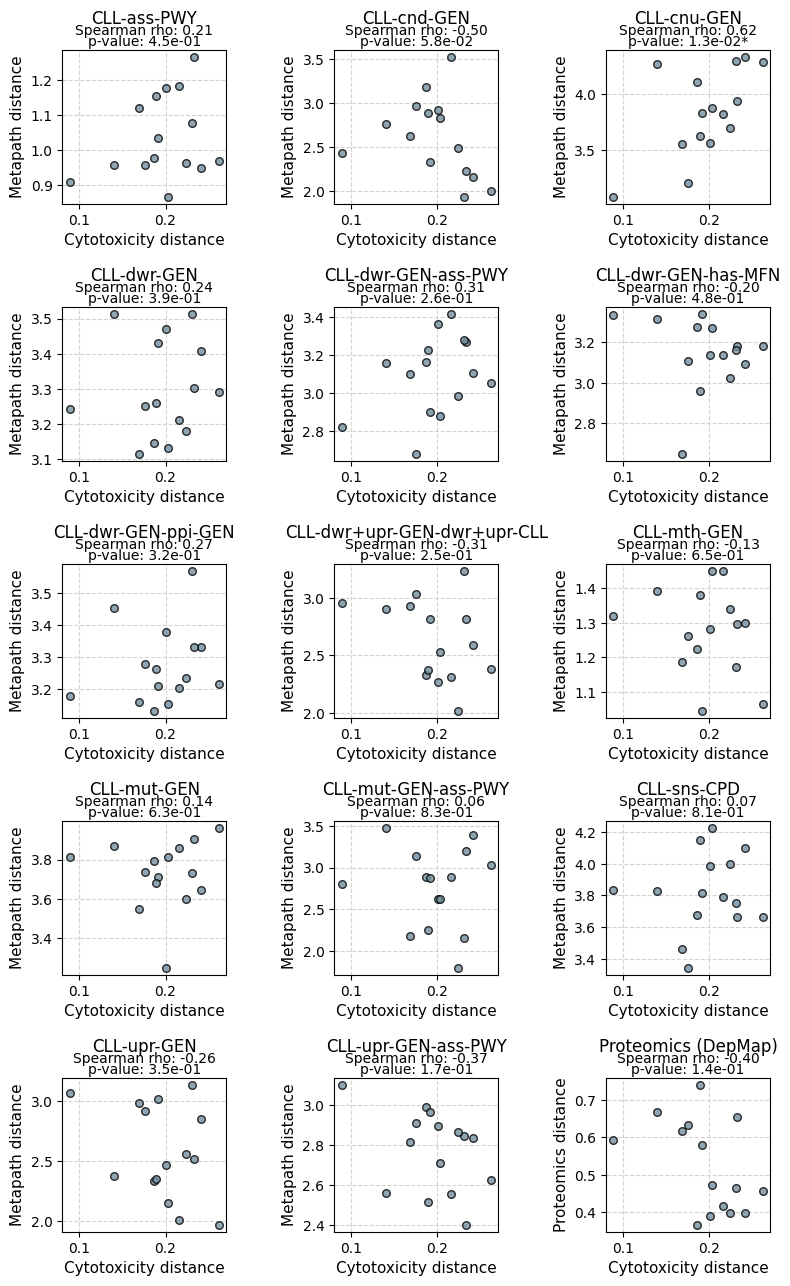

In [43]:
# Create the figure and subplots
fig, axs = plt.subplots(5, 3, figsize=(8, 13))
axs_flat = axs.flatten()

for i, mp in enumerate(mps + ["proteomics"]):
    # Plot each subplot
    if mp == "proteomics":
        plot_correlation_supplementary(
            axs_flat[i],
            sensitivity_distances_flat_pc,
            mps_distances[mp],
            "Proteomics (DepMap)",
            "Cytotoxicity distance",
            "Proteomics distance",
        )
    else:
        plot_correlation_supplementary(
            axs_flat[i],
            sensitivity_distances_flat_pc,
            mps_distances[mp],
            "%s" % mp,
            "Cytotoxicity distance",
            "Metapath distance",
        )

# Save and show
plt.tight_layout()
plt.show()

28
15
21
15
CLL-ass-PWY: 15 distance pairs plotted
CLL-cnd-GEN: 15 distance pairs plotted
CLL-cnu-GEN: 15 distance pairs plotted
CLL-dwr-GEN: 15 distance pairs plotted
CLL-dwr-GEN-ass-PWY: 15 distance pairs plotted
CLL-dwr-GEN-has-MFN: 15 distance pairs plotted
CLL-dwr-GEN-ppi-GEN: 15 distance pairs plotted
CLL-dwr+upr-GEN-dwr+upr-CLL: 15 distance pairs plotted
CLL-mth-GEN: 15 distance pairs plotted
CLL-mut-GEN: 15 distance pairs plotted
CLL-mut-GEN-ass-PWY: 15 distance pairs plotted
CLL-sns-CPD: 15 distance pairs plotted
CLL-upr-GEN: 15 distance pairs plotted
CLL-upr-GEN-ass-PWY: 15 distance pairs plotted
proteomics: 15 distance pairs plotted


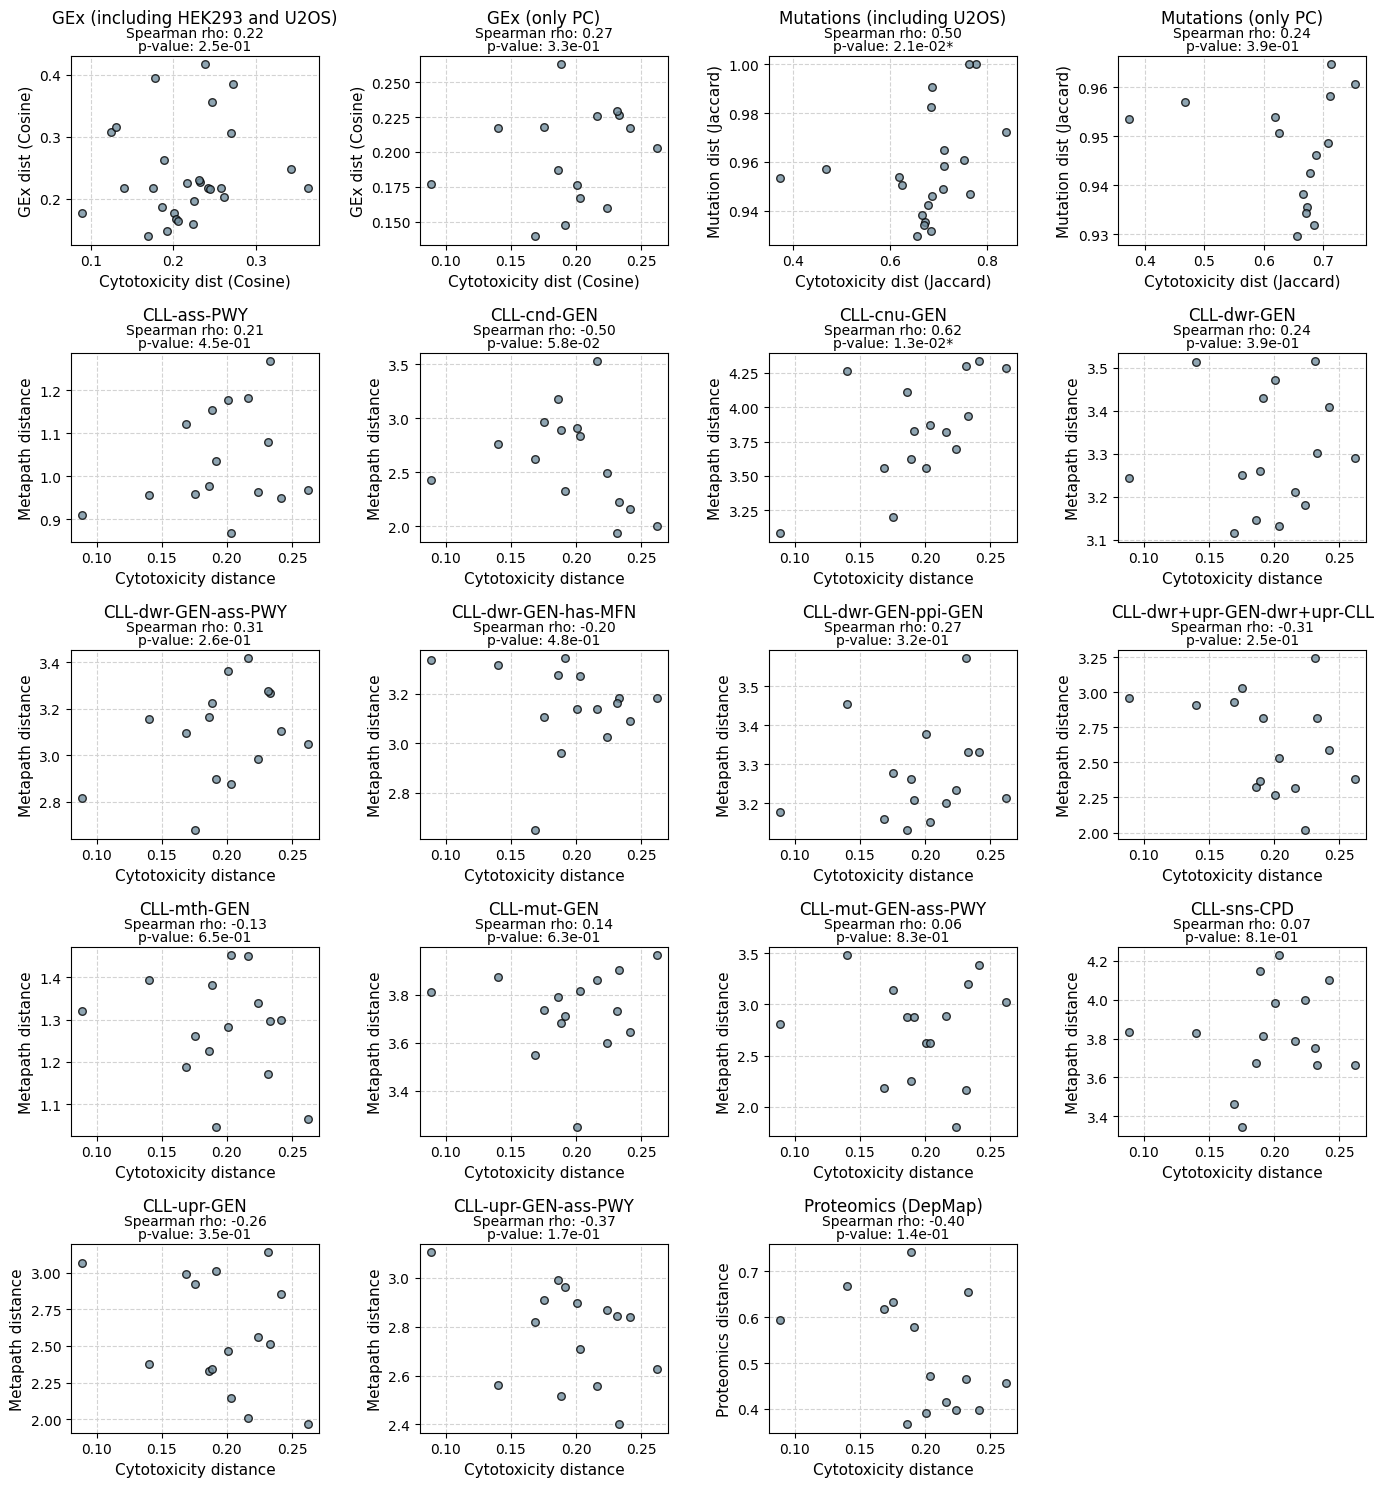

In [44]:
import matplotlib.pyplot as plt

# 1. Setup the grid: 5 rows, 4 columns for a total of 19 active plots
fig, axes = plt.subplots(5, 4, figsize=(14, 15))
axes_flat = axes.flatten()

# --- PART 1: The first 4 specific correlation plots ---
# Using the first 4 slots (0, 1, 2, 3)
plot_correlation_supplementary(
    axes_flat[0],
    sensitivity_distances_flat,
    gex_distances_flat,
    "GEx (including HEK293 and U2OS)",
    "Cytotoxicity dist (Cosine)",
    "GEx dist (Cosine)",
)
print(len(sensitivity_distances_flat))

plot_correlation_supplementary(
    axes_flat[1],
    sensitivity_distances_flat_pc,
    gex_distances_flat_pc,
    "GEx (only PC)",
    "Cytotoxicity dist (Cosine)",
    "GEx dist (Cosine)",
)
print(len(sensitivity_distances_flat_pc))

plot_correlation_supplementary(
    axes_flat[2],
    sensitivity_distances_flat_nohek_binary,
    mut_distances_flat,
    "Mutations (including U2OS)",
    "Cytotoxicity dist (Jaccard)",
    "Mutation dist (Jaccard)",
)
print(len(sensitivity_distances_flat_nohek_binary))

plot_correlation_supplementary(
    axes_flat[3],
    sensitivity_distances_flat_pc_binary,
    mut_distances_flat_pc,
    "Mutations (only PC)",
    "Cytotoxicity dist (Jaccard)",
    "Mutation dist (Jaccard)",
)
print(len(sensitivity_distances_flat_pc_binary))

# --- PART 2: The supplementary 15 plots ---
# We start from index 4 and go to 18
mps_list = mps + ["proteomics"]
for i, mp in enumerate(mps_list):
    target_ax = axes_flat[i + 4] # Offset by 4 to skip the first row
    
    if mp == "proteomics":
        plot_correlation_supplementary(
            target_ax,
            sensitivity_distances_flat_pc,
            mps_distances[mp],
            "Proteomics (DepMap)",
            "Cytotoxicity distance",
            "Proteomics distance",
        )
    else:
        plot_correlation_supplementary(
            target_ax,
            sensitivity_distances_flat_pc,
            mps_distances[mp],
            f"{mp}",
            "Cytotoxicity distance",
            "Metapath distance",
        )
    print(f"{mp}: {len(mps_distances[mp])} distance pairs plotted")

# 2. Hide the unused 20th subplot (index 19)
axes_flat[-1].set_visible(False)

# 3. Final formatting and saving
plt.tight_layout()
plt.show()